In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
train = pd.read_csv('Bigmart_train.csv')
test = pd.read_csv('Bigmart_test.csv')

In [3]:
train.shape

(8523, 12)

In [4]:
test.shape

(5681, 11)

In [5]:
train.isna().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

<Axes: xlabel='Item_Outlet_Sales', ylabel='Count'>

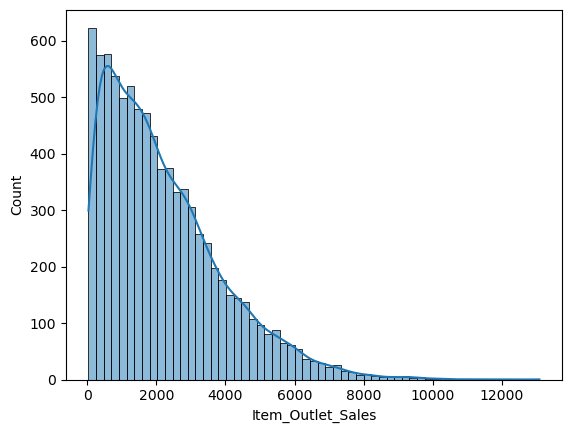

In [6]:
sns.histplot(train['Item_Outlet_Sales'], kde=True)

<Axes: ylabel='Item_Outlet_Sales'>

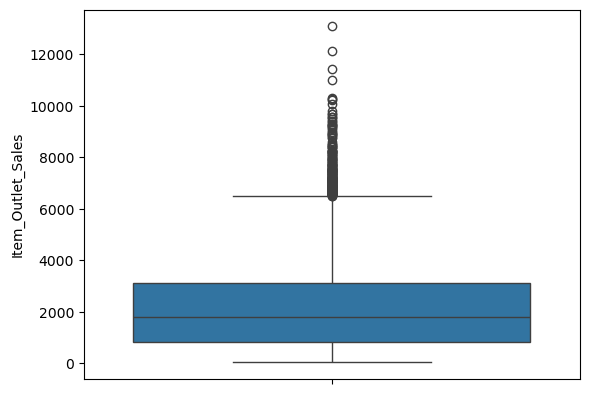

In [7]:
sns.boxplot(train['Item_Outlet_Sales'])

In [8]:
num_cols = train.select_dtypes(include = np.number).columns.tolist()

In [9]:
num_cols

['Item_Weight',
 'Item_Visibility',
 'Item_MRP',
 'Outlet_Establishment_Year',
 'Item_Outlet_Sales']

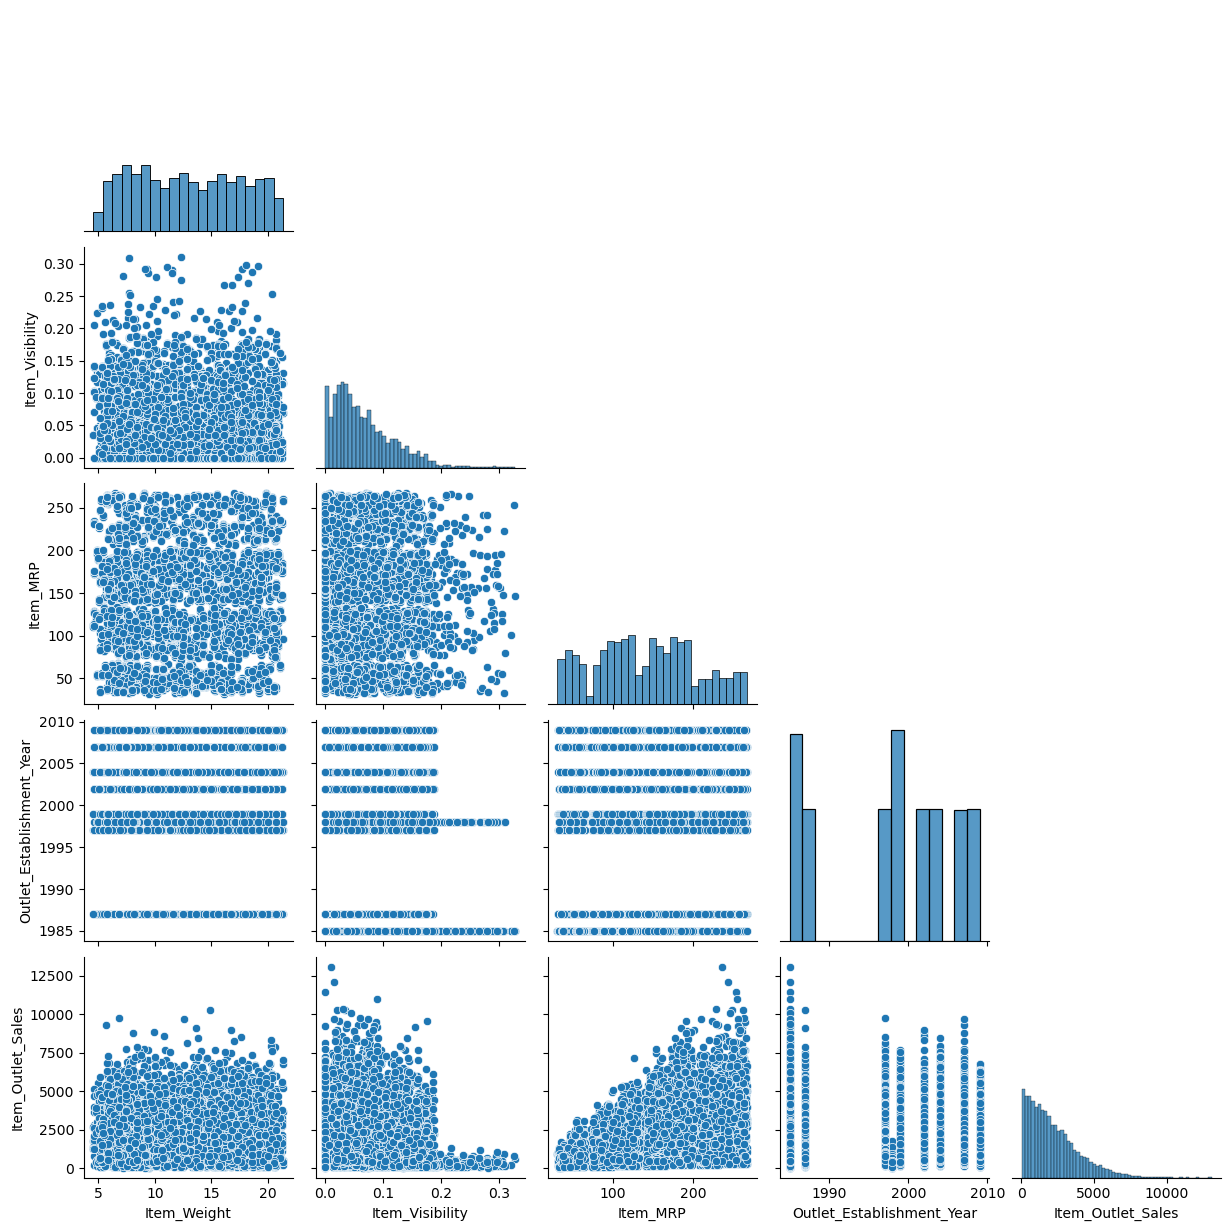

In [10]:
sns.pairplot(train[num_cols],corner=True)

In [11]:
'''
1. Strong linear relationship (MRP-Sales)
2. Weak relationships (visibility and weight vs Sales)
3. Distributions along the diagonal reveal right-skewness.. WE can do log-transformations before modelling for this..
Preprocessings:
1. LF - Regular fix
2. Itemweight - Missing values - MEan
3. Outlet_size - Missing values - Mode
4. Item_Visibility - fix 0s with Median
'''

'\n1. Strong linear relationship (MRP-Sales)\n2. Weak relationships (visibility and weight vs Sales)\n3. Distributions along the diagonal reveal right-skewness.. WE can do log-transformations before modelling for this..\nPreprocessings:\n1. LF - Regular fix\n2. Itemweight - Missing values - MEan\n3. Outlet_size - Missing values - Mode\n4. Item_Visibility - fix 0s with Median\n'

In [12]:
CURRENT_YEAR = 2013
for df in [train, test]:
    # Strandadize labels
    df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({'LF':'Low Fat', 'low fat' :'Low Fat', 'reg':'Regular' })

    # Fill the NaN values in Item_Weight, Outlet Size using the calculated group values
    df['Item_Weight'].fillna(df.groupby(['Item_Identifier'])['Item_Weight'].transform('median'), inplace=True)
    df['Item_Weight'].fillna(df.groupby(['Item_Type'])['Item_Weight'].transform('mean'), inplace=True)
    df['Outlet_Size'] = df.groupby('Outlet_Type')['Outlet_Size'].transform(lambda x: x.fillna(x.mode()[0]))

    # replace 0 values in Item_visibility using the calculated group values
    df['Item_Visibility'] = df.groupby('Item_Identifier')['Item_Visibility'].transform(lambda x: x.replace(0, x.median()))
    #Features
    df['Outlet_Age'] = CURRENT_YEAR - df['Outlet_Establishment_Year']
    df['Item_Category'] = df['Item_Identifier'].apply(lambda x: x[:2])
    df['Visibility_MeanRatio'] = df['Item_Visibility']/df['Item_Visibility'].mean()
    df['Outlet_Location_Score'] = df['Outlet_Location_Type'].map({'Tier 1': 1, 'Tier 2': 2, 'Tier 3' : 3})
    df['High_MRP_Flag'] = (df['Item_MRP'] > df['Item_MRP'].median()).astype(int)

    #df['Outlet_MRP_Avg'] = df.groupby('Outlet_Identifier')['Item_MRP'].transform('mean')
    #df['Relative_MRP'] = df['Item_MRP'] / df['Outlet_MRP_Avg']

In [13]:
train.to_csv('preprocessed_train.csv', index = False)
test.to_csv('preprocessed_test.csv', index = False)

In [14]:
train.head(5)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Outlet_Age,Item_Category,Visibility_MeanRatio,Outlet_Location_Score,High_MRP_Flag
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,14,FD,0.228598,1,1
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,4,DR,0.274624,3,0
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,14,FD,0.238752,1,0
3,FDX07,19.20,Regular,0.022861,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,15,FD,0.325664,3,1
4,NCD19,8.93,Low Fat,0.006590,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,26,NC,0.093872,3,0


In [15]:
num_cols = train.select_dtypes(include=np.number).columns.tolist()
train[num_cols].corr()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Outlet_Age,Visibility_MeanRatio,Outlet_Location_Score,High_MRP_Flag
Item_Weight,1.000000,-0.019480,0.025967,-0.013417,0.013198,0.013417,-0.019480,0.002973,0.024840
Item_Visibility,-0.019480,1.000000,-0.004780,-0.076000,-0.127717,0.076000,1.000000,-0.031468,0.004436
Item_MRP,0.025967,-0.004780,1.000000,0.005020,0.567574,-0.005020,-0.004780,0.000232,0.843347
Outlet_Establishment_Year,-0.013417,-0.076000,0.005020,1.000000,-0.049135,-1.000000,-0.076000,-0.089216,-0.005651
Item_Outlet_Sales,0.013198,-0.127717,0.567574,-0.049135,1.000000,0.049135,-0.127717,0.089367,0.485460
Outlet_Age,0.013417,0.076000,-0.005020,-1.000000,0.049135,1.000000,0.076000,0.089216,0.005651
Visibility_MeanRatio,-0.019480,1.000000,-0.004780,-0.076000,-0.127717,0.076000,1.000000,-0.031468,0.004436
Outlet_Location_Score,0.002973,-0.031468,0.000232,-0.089216,0.089367,0.089216,-0.031468,1.000000,-0.004603
High_MRP_Flag,0.024840,0.004436,0.843347,-0.005651,0.485460,0.005651,0.004436,-0.004603,1.000000


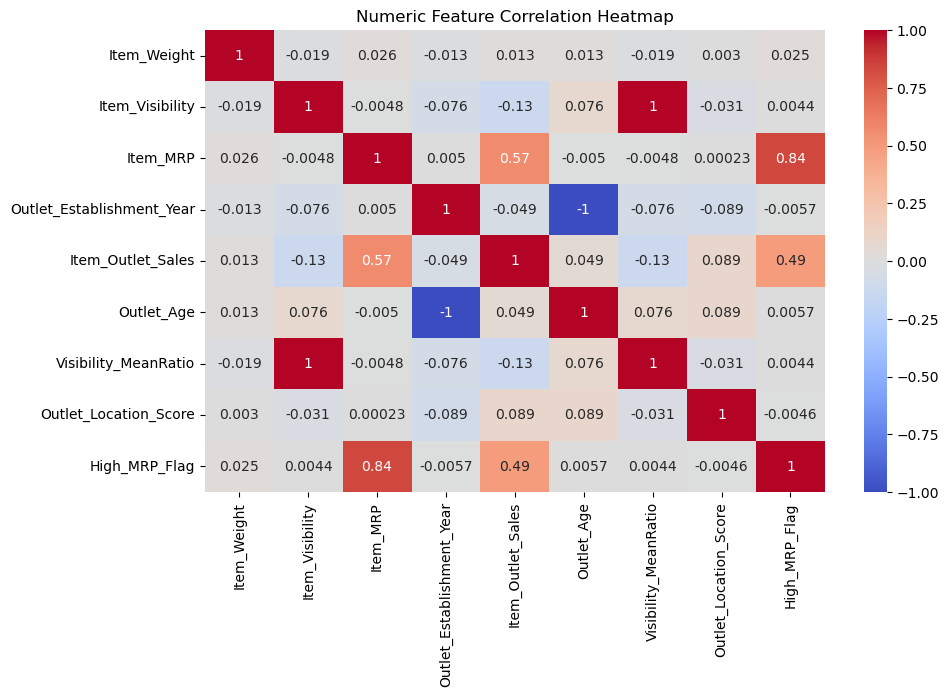

In [16]:
# Correlation heatmap (numeric features) Pearson Coefficent

plt.figure(figsize=(10,6))
sns.heatmap(train[num_cols].corr(), cmap='coolwarm', annot=True)
plt.title("Numeric Feature Correlation Heatmap")
plt.show()
     

In [17]:
#Chi square test for categorical vs target
from scipy.stats import chi2_contingency

cat_cols = train.select_dtypes(exclude=np.number).columns
chi_results=[]

#chi square test for variance
for c in cat_cols:
    contingency = pd.crosstab(train[c], pd.qcut(train['Item_Outlet_Sales'], q=4))
    chi2_stat, p, dof,ex = chi2_contingency(contingency)
    chi_results.append((c,chi2_stat,p))
    #H0 - No association between each categorical variable and binned sales
    #HA - Strong Relationship (p<0.05) reject Null
chi_df = pd.DataFrame(chi_results, columns=["Feature","Chi2","p_value"]).sort_values("p_value")
print("Chi-Square association with Item_Outlet_Sales (lower p = stronger association):")
display(chi_df)


Chi-Square association with Item_Outlet_Sales (lower p = stronger association):


,Feature,Chi2,p_value
3,Outlet_Identifier,3679.210196,0.000000e+00
6,Outlet_Type,3647.922343,0.000000e+00
0,Item_Identifier,7454.138969,1.486821e-132
4,Outlet_Size,478.120972,4.334800e-100
5,Outlet_Location_Type,282.177067,5.372026e-58
7,Item_Category,27.515132,1.159189e-04
2,Item_Type,88.372933,1.204309e-04
1,Item_Fat_Content,5.429388,1.429235e-01


In [18]:
y = train['Item_Outlet_Sales'] # target
features = ["Item_Weight",'Item_Visibility','Item_MRP','Outlet_Age','Outlet_Location_Score','Item_Type','Item_Category',
            'Outlet_Size','Outlet_Location_Type','Outlet_Type','Outlet_Identifier']
X = train[features]
X_test = test[features]

In [19]:
num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude = np.number).columns

In [20]:
num_cols

Index(['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Age',
       'Outlet_Location_Score'],
      dtype='object')

In [21]:
cat_cols

Index(['Item_Type', 'Item_Category', 'Outlet_Size', 'Outlet_Location_Type',
       'Outlet_Type', 'Outlet_Identifier'],
      dtype='object')

In [22]:
preprocessor = ColumnTransformer([('num',StandardScaler(),num_cols),('categoricsl',OneHotEncoder(handle_unknown='ignore',drop='first',sparse_output=False),cat_cols)])

In [23]:
line_pipe = Pipeline([('prep',preprocessor),('model', LinearRegression())])

In [24]:
line_pipe.fit(X,y) # Gradient Descent

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('categoricsl', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [25]:
y_pred = line_pipe.predict(X)

In [26]:

r2 = r2_score(y,y_pred)
rmse = np.sqrt(mean_squared_error(y,y_pred))

In [27]:
r2

0.5636142443775545

In [28]:
rmse

np.float64(1127.238980661861)

In [29]:
preds = line_pipe.predict(X_test)

In [30]:
preds

array([1851.1652192 , 1495.80391713, 1883.68523012, ..., 1826.34911107,
       3545.42316405, 1268.24060569], shape=(5681,))

In [31]:
preds = np.clip(preds,0,None)

In [32]:
preds

array([1851.1652192 , 1495.80391713, 1883.68523012, ..., 1826.34911107,
       3545.42316405, 1268.24060569], shape=(5681,))

In [33]:
submission = pd.DataFrame(
    {
        'Item_Identifier':test['Item_Identifier'],
        'Outlet_Identifier' : test['Outlet_Identifier'],
        'Item_Outlet_Sales' : preds
    }
)

In [34]:
submission.to_csv("Submission_LR_CF.csv", index = False)

In [44]:
#create a pickle file to save the model
import joblib
joblib.dump(line_pipe,'bigmart_model.pkl')



['bigmart_model.pkl']

In [35]:
from sklearn.linear_model import SGDRegressor 
gd_line_pipe = Pipeline([('prep', preprocessor), ('model', SGDRegressor())])
gd_line_pipe.fit(X,y)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('categoricsl', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [36]:
gd_y_pred = gd_line_pipe.predict(X)

In [37]:
r2 = r2_score(y,gd_y_pred)
rmse = np.sqrt(mean_squared_error(y,gd_y_pred))

In [38]:
r2


0.5628396639526034

In [39]:
rmse

np.float64(1128.2389561748003)

In [40]:
gd_preds = gd_line_pipe.predict(X_test)

In [41]:
gd_preds = np.clip(gd_preds,0,None)

In [42]:
submission = pd.DataFrame(
    {
        'Item_Identifier':test['Item_Identifier'],
        'Outlet_Identifier' : test['Outlet_Identifier'],
        'Item_Outlet_Sales' : gd_preds
    }
)

In [43]:
submission.to_csv("GD_Submission_LR_CF.csv", index = False)